# Exploratory Data Analysis of Passiv UK Temperature Time Series Data

In [ ]:
import ast
from datetime import datetime
from matplotlib.dates import DayLocator, DateFormatter, HourLocator
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path


In [36]:
# load files

data_path = Path("PST_Data_20260220")

houses = {}

for file in data_path.glob("*.csv"):
    house_id = file.stem.split("_")[0]
    if "_Events_" in file.stem:
        file_type = "events"
    else:
        file_type = "readings"    
    houses.setdefault(house_id, {})[file_type] = pd.read_csv(file)

In [37]:
houses["28190"]["readings"].head()

,Time (UTC),Room temperature (Zone 1) (°C),Room temperature (Zone 2) (°C),Setpoint temperature (Zone 1) (°C),Setpoint temperature (Zone 2) (°C),Space heating (0/1),Zone 1 heating (0/1),Zone 2 heating (0/1),Flow temperature setpoint (°C),Hot water temperature (°C),Hot water usage setting,Hot water (0/1),Immersion call (0/1),Immersion status (0/1),Hot water setpoint (°C),Flow temperature (°C),Return temperature (°C),Defrost status (0/1),Tariff rate (p/kWh),External temperature (°C)
0,2025-10-07 07:10,17.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,17.6,NaN,0.0,NaN,NaN,NaN,12.6,12.9,0.0,NaN,NaN
1,2025-10-07 07:15,17.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,17.6,NaN,0.0,NaN,NaN,NaN,12.6,12.9,0.0,NaN,NaN
2,2025-10-07 07:20,17.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,17.6,NaN,0.0,0.0,NaN,NaN,12.6,12.9,0.0,NaN,NaN
3,2025-10-07 07:25,17.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,17.6,NaN,0.0,0.0,NaN,30.0,12.6,12.9,0.0,NaN,NaN
4,2025-10-07 07:30,17.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,17.6,NaN,0.0,0.0,NaN,30.0,12.7,12.9,0.0,NaN,NaN


In [38]:
houses["28190"]["events"].head()

,Timestamp,Type,Payload
0,2025-10-09 12:30:47,Schedule,"{'type': 'heating', 'zone': 1, 'mode': 'advanc..."
1,2025-10-09 12:30:47,Schedule,"{'type': 'hot_water', 'mode': 'advanced', 'lay..."
2,2025-10-09 12:30:47,Schedule,"{'uri': '/v/1/schedule/away', 'type': 'away', ..."
3,2025-10-09 12:30:47,Schedule,"{'type': 'heating', 'zone': 1, 'mode': 'basic'..."
4,2025-10-09 12:30:47,Schedule,"{'type': 'hot_water', 'mode': 'basic', 'layers..."


In [39]:
datapoints_in_day = 12 * 24
datapoints_in_week = datapoints_in_day * 7

In [40]:
# extract override event data

def extract_override(payload):
    
    try:
        payload = ast.literal_eval(payload)
    except Exception:
        return []
    
    overrides = []
    
    for layer in payload.get("layers", []):
        if "override" in layer:
            override = layer["override"]
            start = pd.to_datetime(override.get("start"))
            end = pd.to_datetime(override.get("end"))
            
            for event in override.get("events", []): 
                temp = event.get("C")
                overrides.append({"start": start, "end": end, "temp": temp})
    
    return overrides

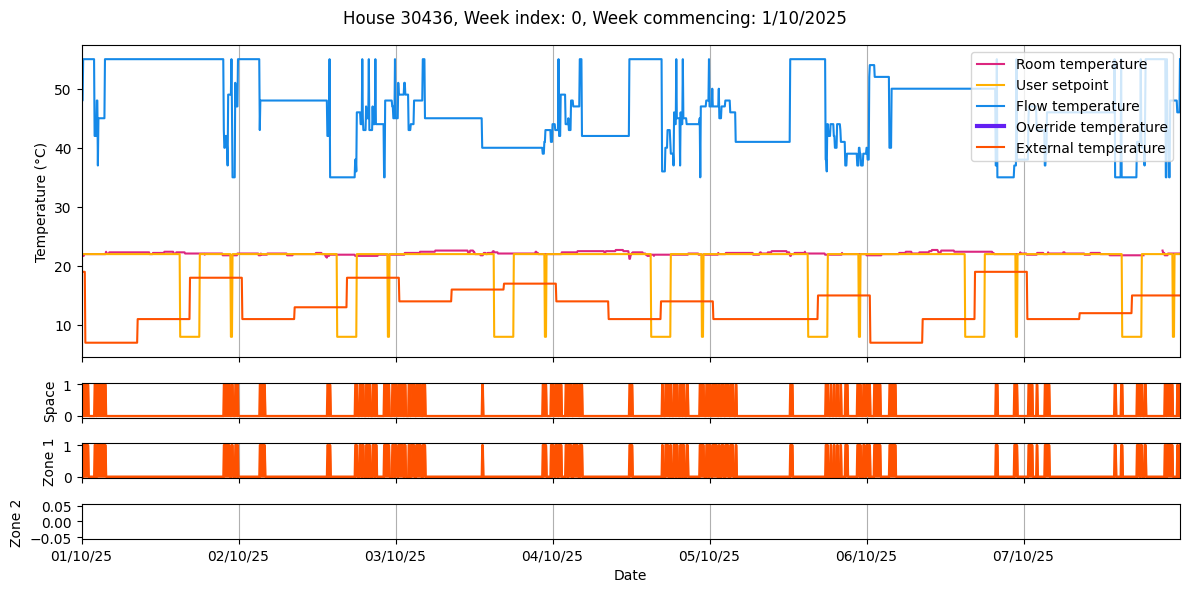

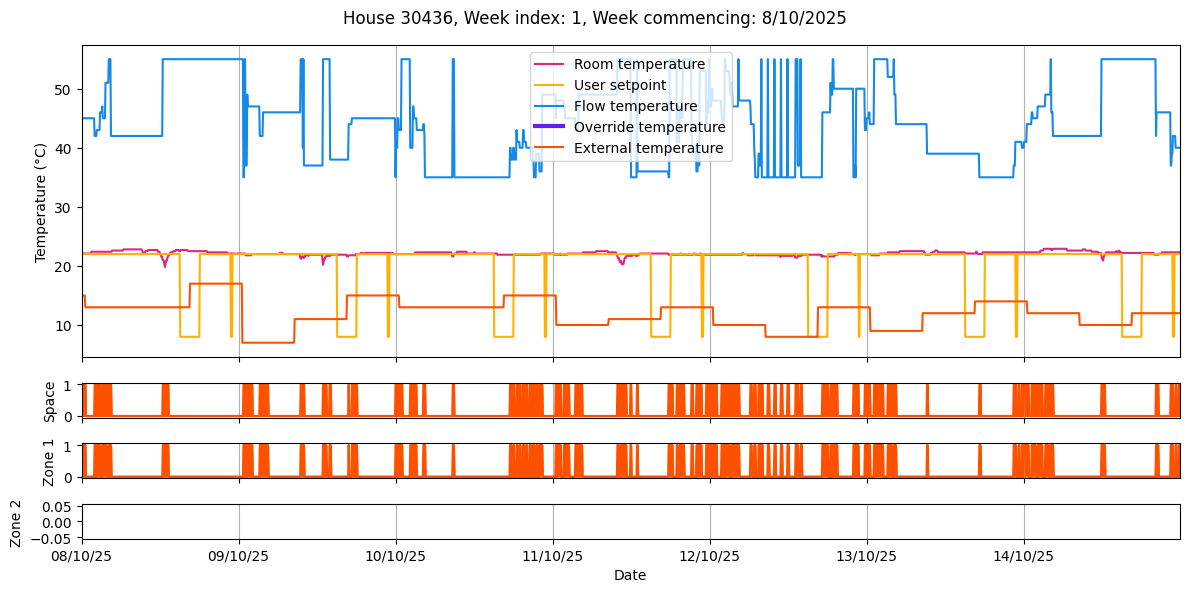

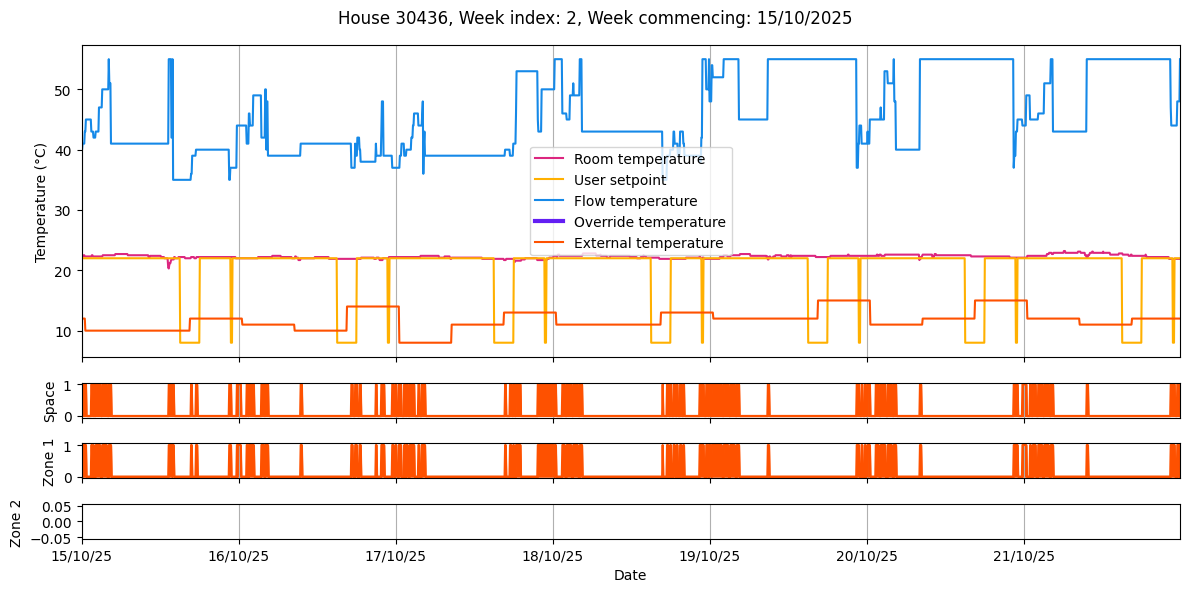

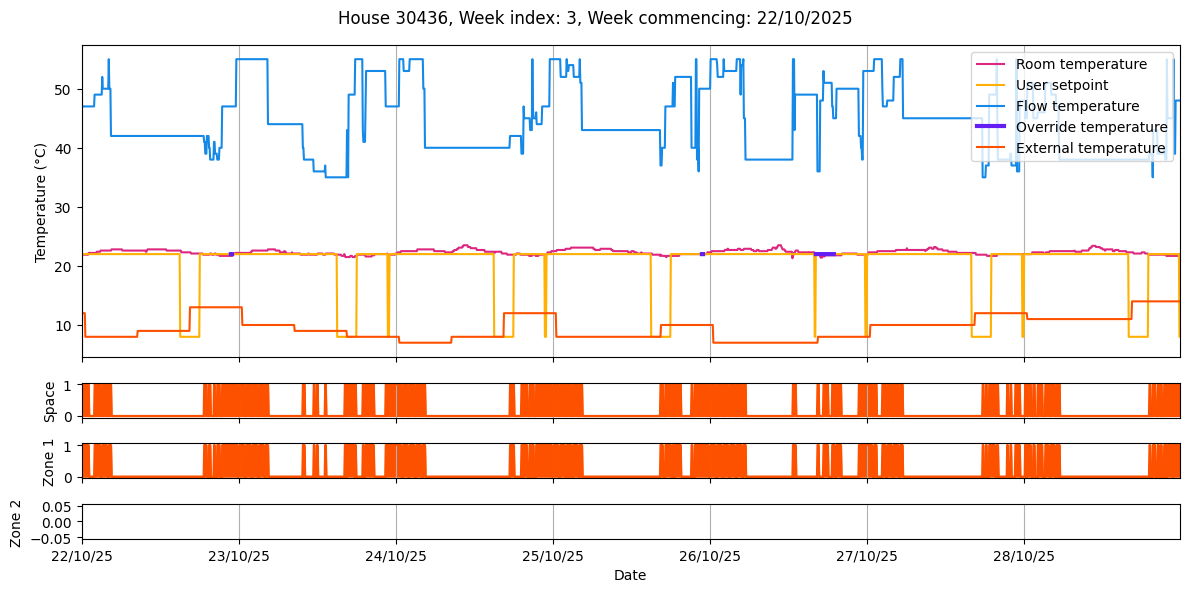

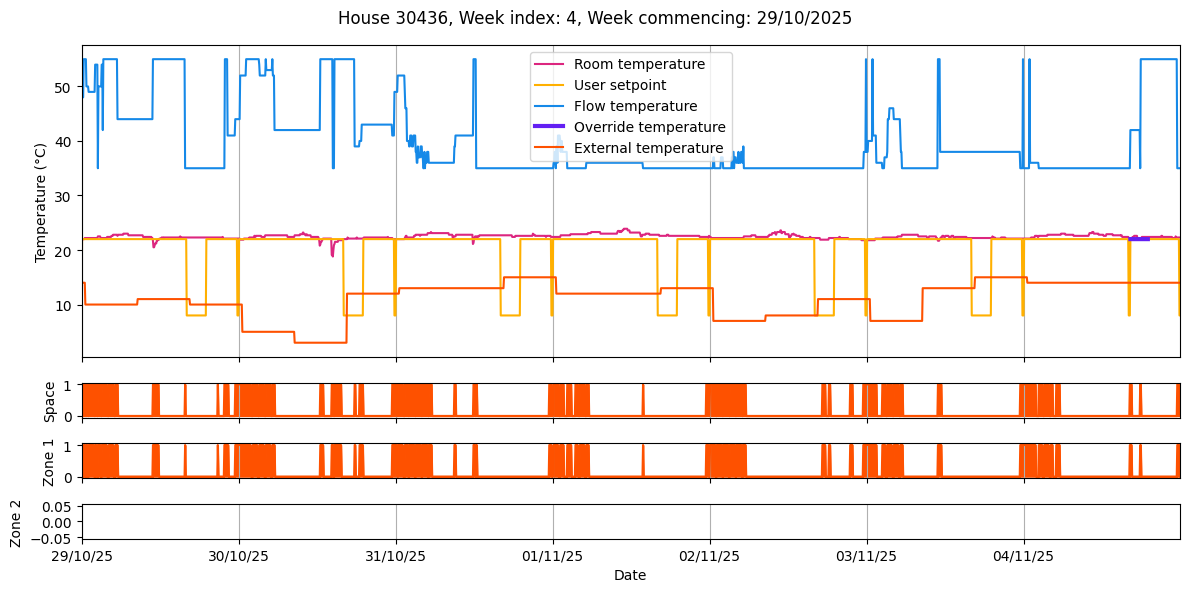

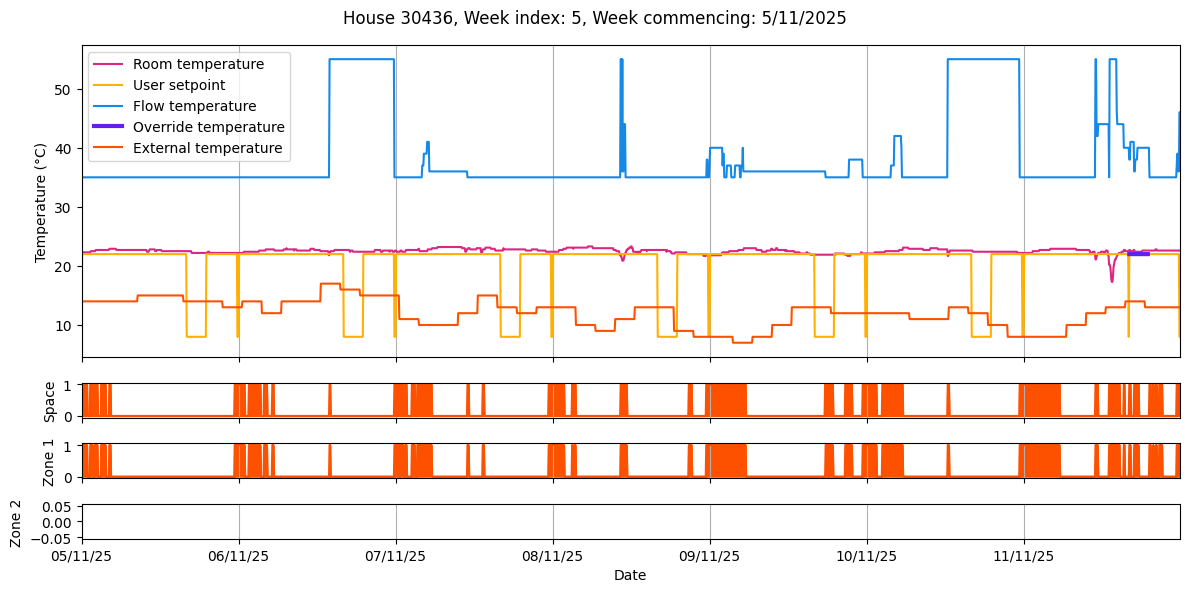

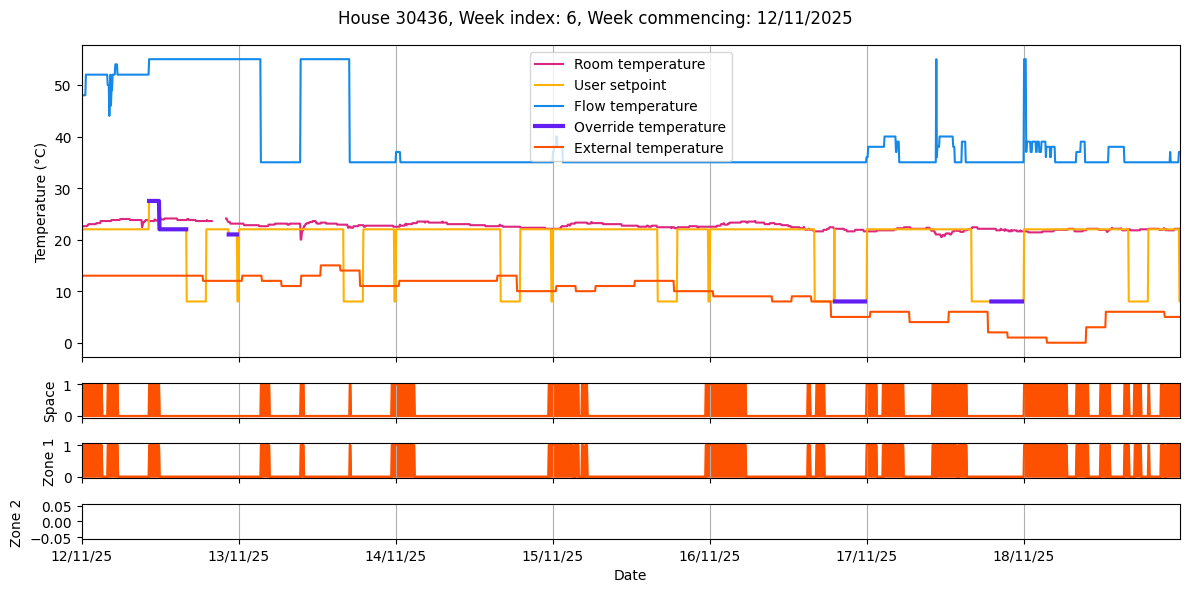

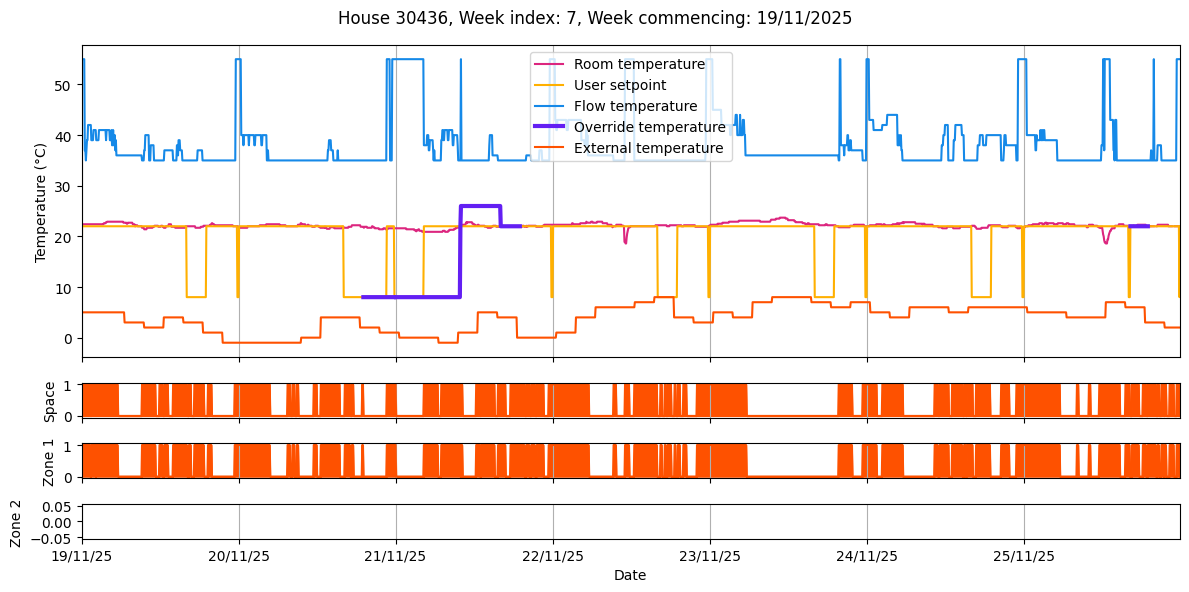

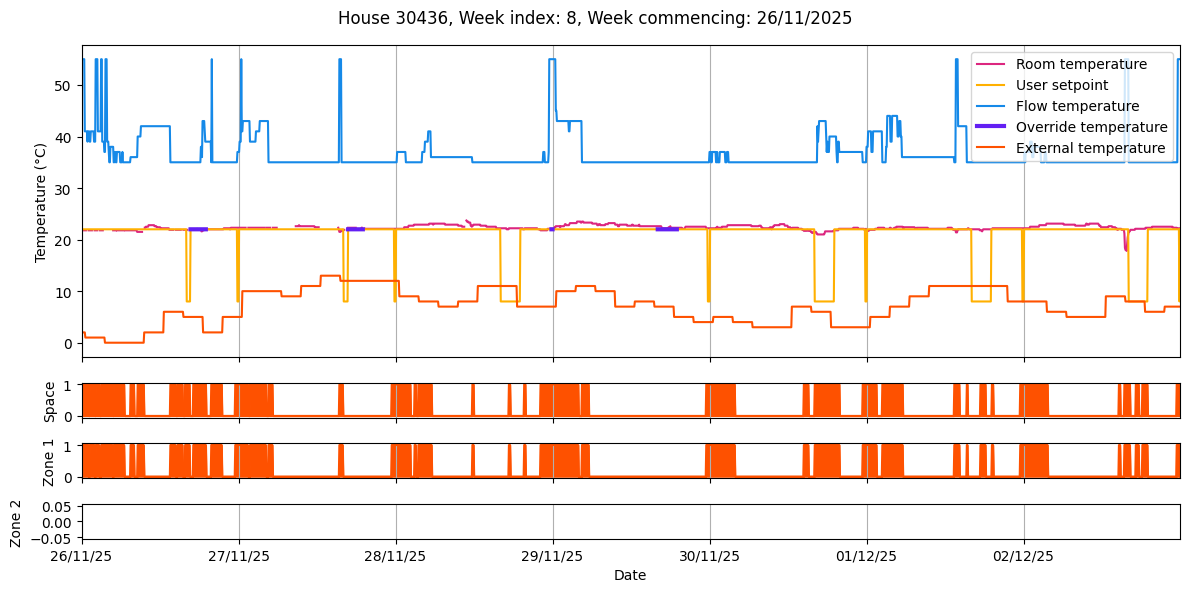

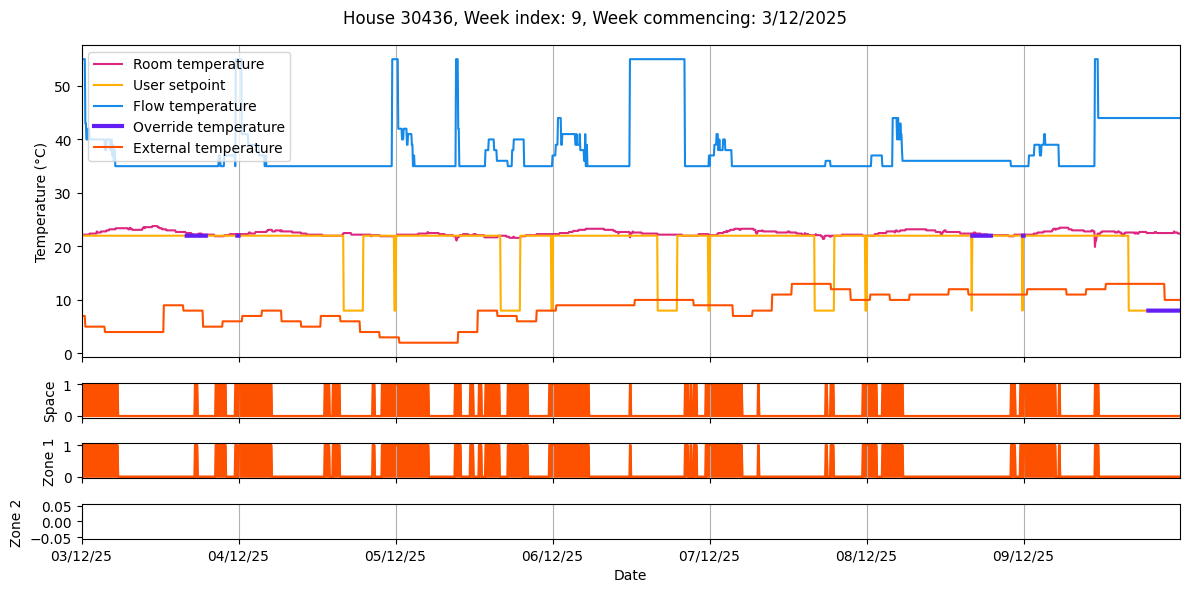

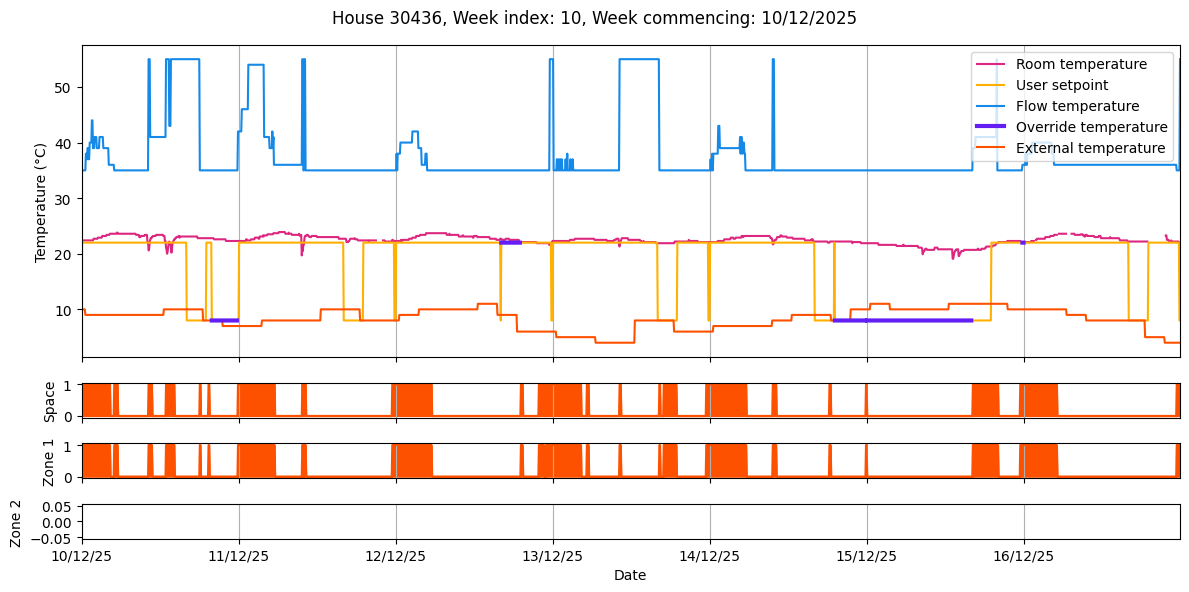

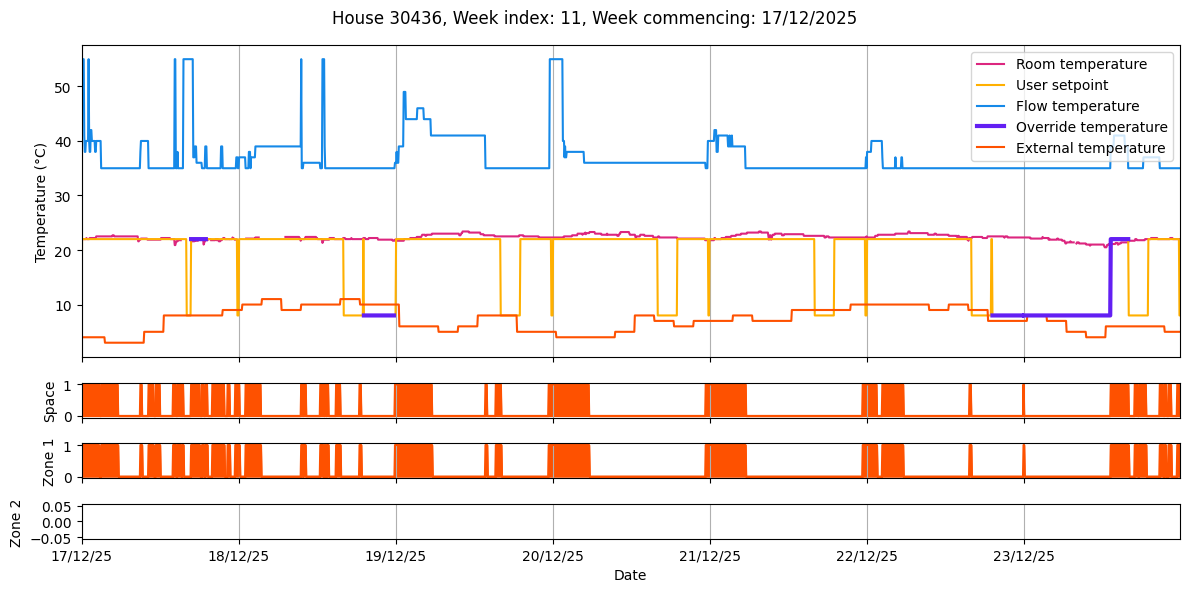

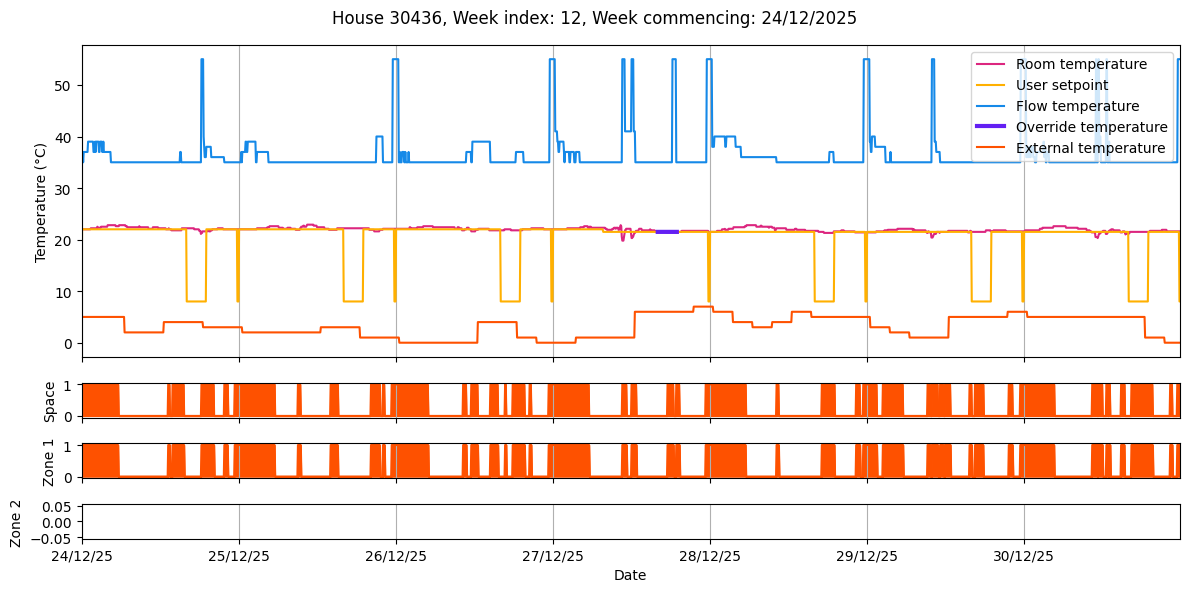

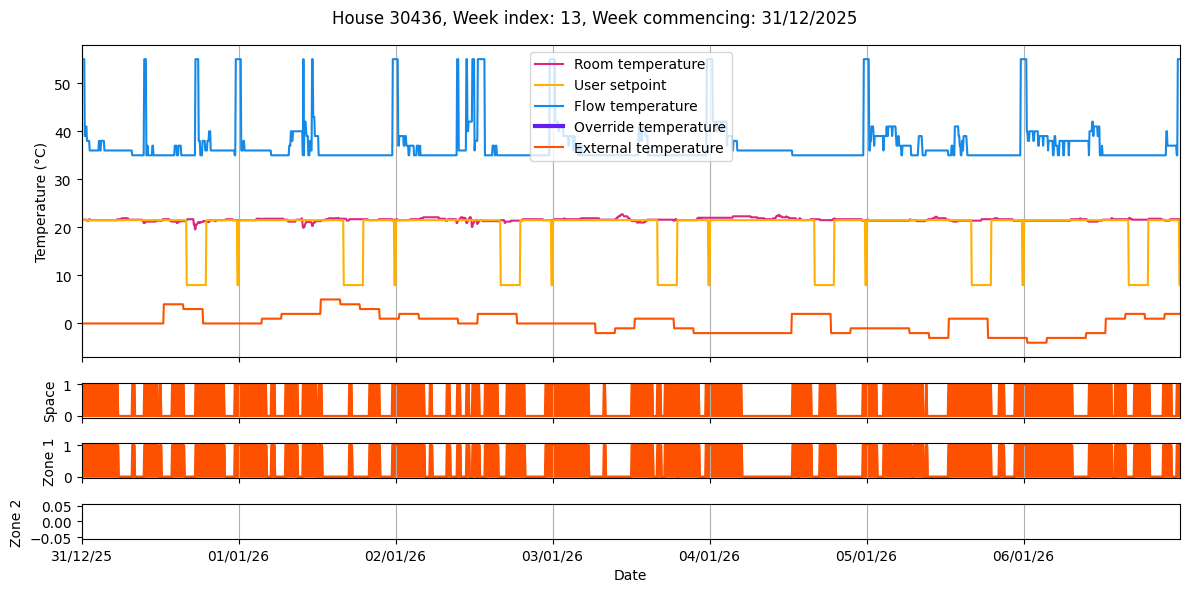

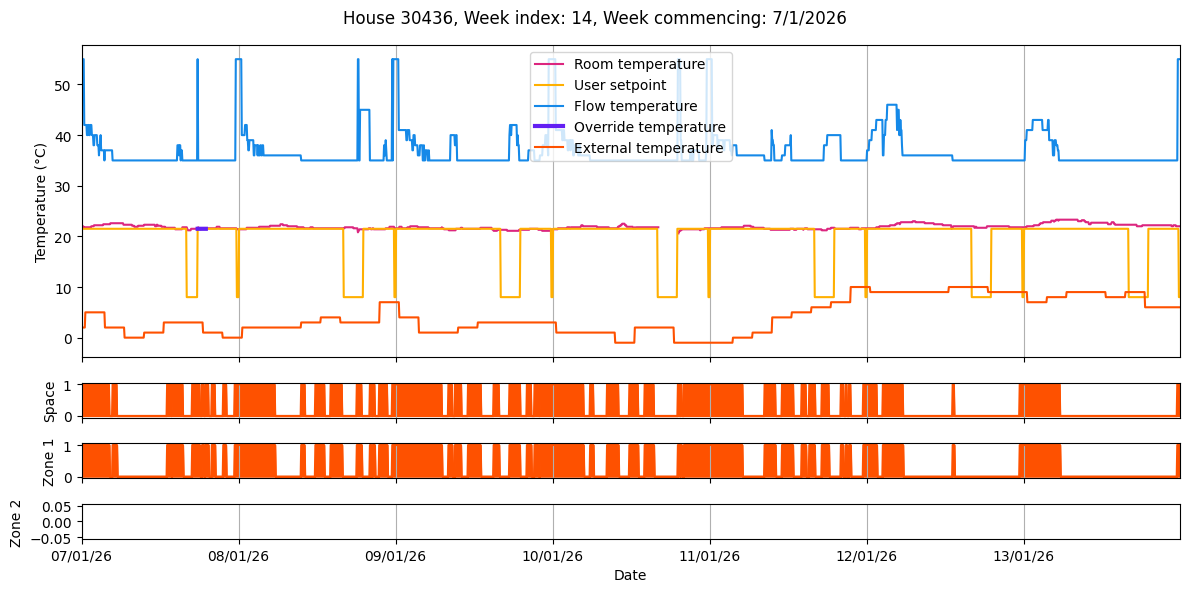

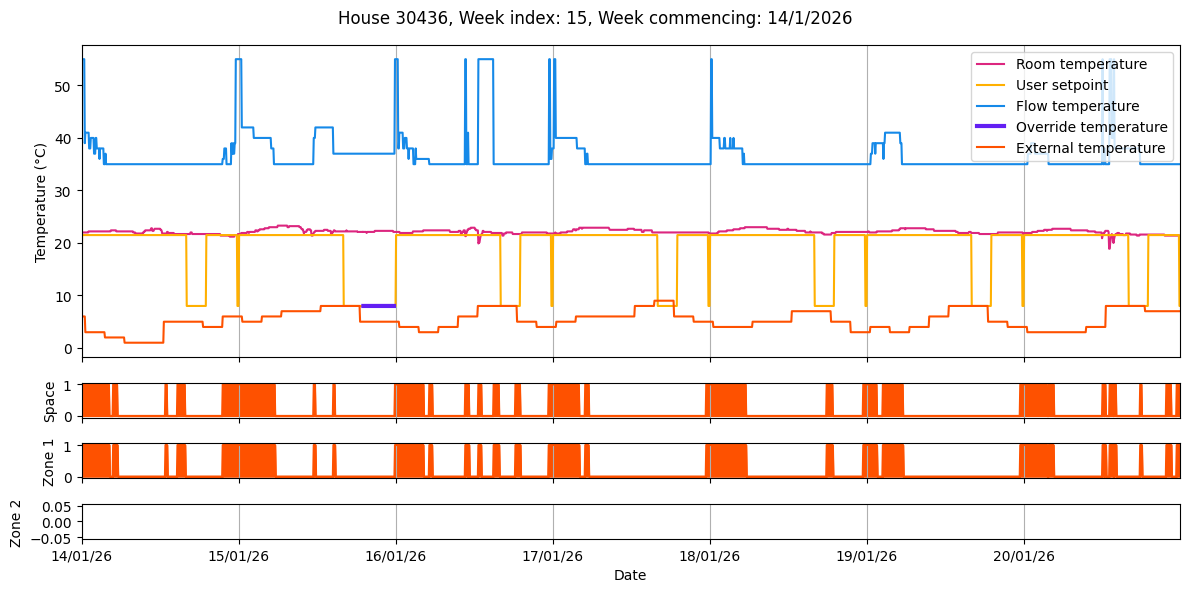

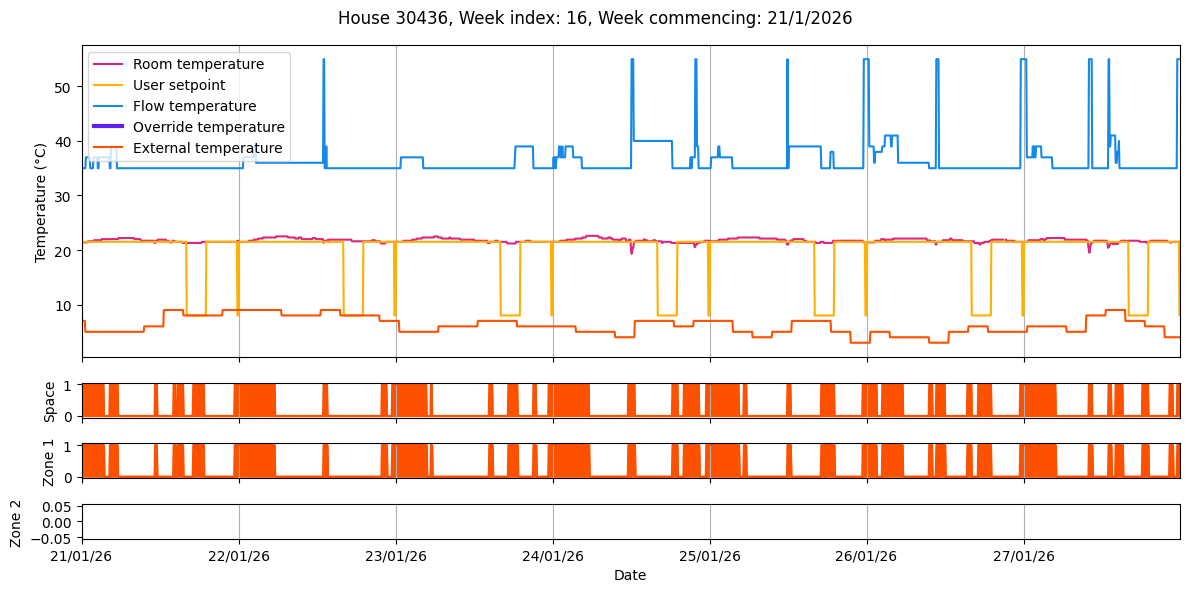

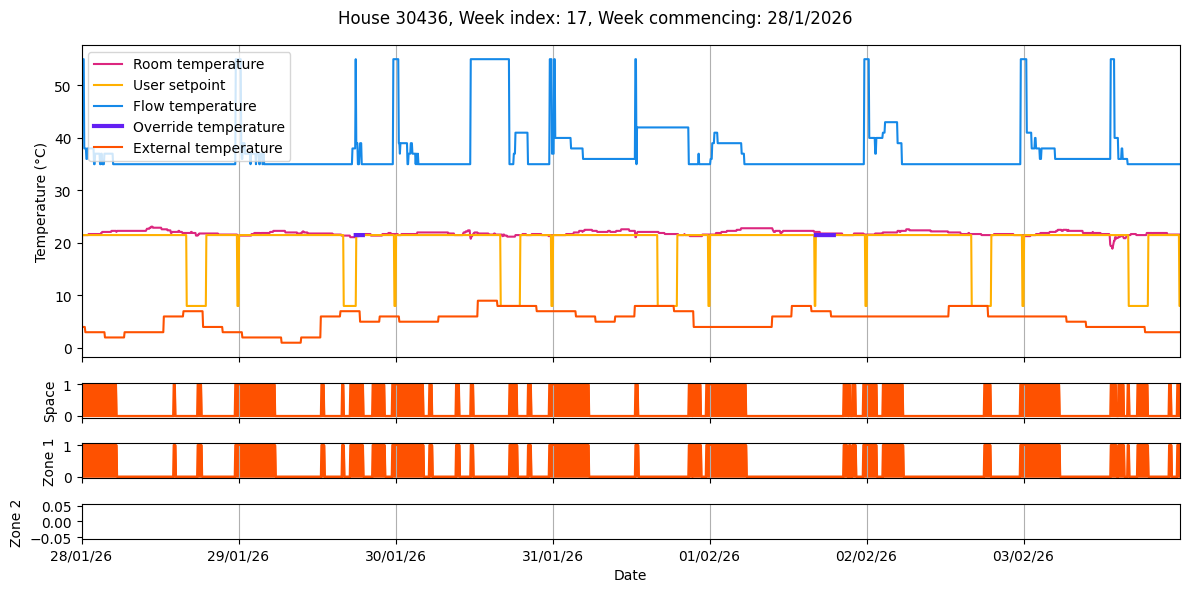

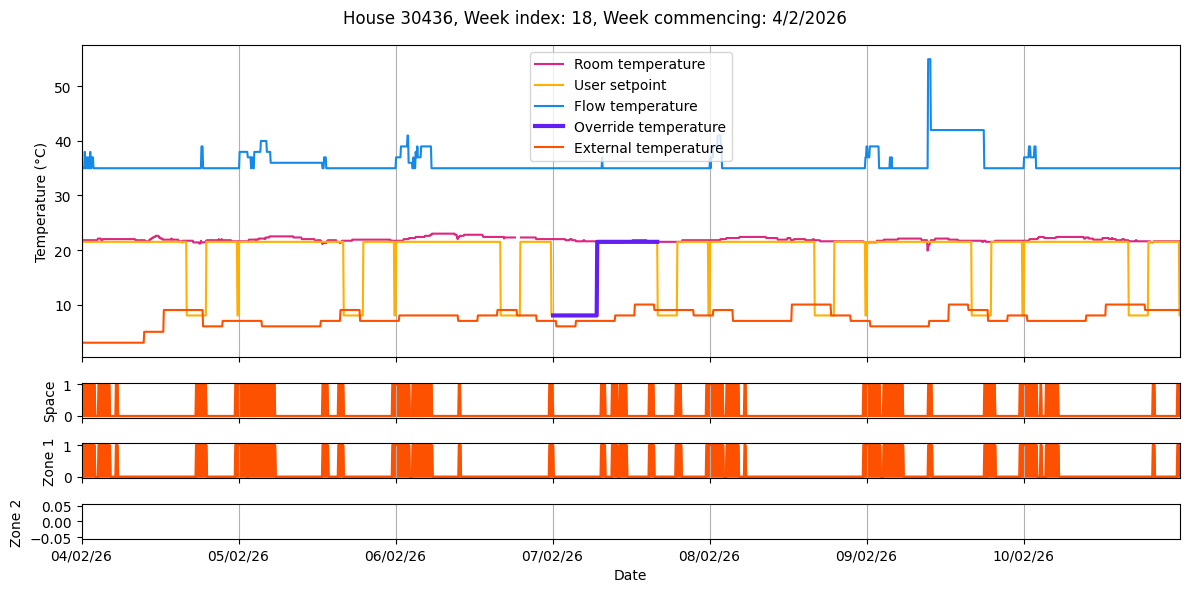

In [43]:
# plotting

colours = ["#dc267f", "#ffb000", "#1589e8", "#631ff3", "#fe5100"] # - IBM colourblind palette
  
# loop through houses  
for house_id, house_data in houses.items():
    
    house_df = house_data["readings"].copy()
    user_df = house_data["events"].copy()
    user_df["OverrideEvents"] = user_df["Payload"].apply(extract_override)
        
    # convert to datetime
    house_df["Datetime"] = pd.to_datetime(house_df["Time (UTC)"], errors="coerce")
    user_df["Eventtime"] = pd.to_datetime(user_df["Timestamp"], errors = "coerce")
    
    house_df["Override temperature (°C)"] = None
    
    # align override temp with override period
    for _, row in user_df.iterrows():
        for override in row["OverrideEvents"]:
            # align readings and events time types
            if hasattr(override["start"], "tzinfo") and override["start"].tzinfo is not None:
                override["start"] = override["start"].tz_convert(None)
            if hasattr(override["end"], "tzinfo") and override["end"].tzinfo is not None:
                override["end"] = override["end"].tz_convert(None)
            # assign override temp with right time period
            mask = (house_df["Datetime"] >= override["start"]) & (house_df["Datetime"] <= override["end"])
            house_df.loc[mask, "Override temperature (°C)"] = override["temp"]
    
    # align override event data and temp reading data by time
    house_user_df = pd.merge_asof(
        house_df.sort_values("Datetime"), 
        user_df.sort_values("Eventtime"), 
        left_on = "Datetime", 
        right_on = "Eventtime", 
        direction = "backward"
    )

    # plot by week
    num_days = int(len(house_user_df) / datapoints_in_day)
    num_weeks = int(num_days / 7)

    for week in range(num_weeks):
        start_week = week * datapoints_in_week
        end_week = start_week + datapoints_in_week
        week_df = house_user_df.iloc[start_week:end_week]
        
        dates = week_df["Datetime"]
        room_temp = week_df["Room temperature (Zone 1) (°C)"]
        user_setpoint = week_df["Setpoint temperature (Zone 1) (°C)"]
        flow_temp = week_df["Flow temperature setpoint (°C)"]
        override_temp = week_df["Override temperature (°C)"]
        
        if "External temperature (°C)" in week_df.columns:
            ext_temp = week_df["External temperature (°C)"]
        else:
            ext_temp = None
        
        space_heating_on = week_df["Space heating (0/1)"]
        zone1_heating_on = week_df["Zone 1 heating (0/1)"]
        
        if "Zone 2 heating (0/1)" in week_df.columns:
            zone2_heating_on = week_df["Zone 2 heating (0/1)"]
        else:
            zone2_heating_on = None
            
        if zone2_heating_on is not None:
            fig, (temp_plot, space_heating_plot, zone1_heating_plot, zone2_heating_plot) = plt.subplots(4, 1, sharex = True, height_ratios = [9, 1, 1, 1], figsize = (12, 6), layout = "tight")
        else:
            fig, (temp_plot, space_heating_plot, zone1_heating_plot) = plt.subplots(3, 1, sharex = True, height_ratios = [9, 1, 1], figsize = (12, 6), layout = "tight")
        
        fig.suptitle(f"House {house_id}, Week index: {week}, Week commencing: {dates[start_week].day}/{dates[start_week].month}/{dates[start_week].year}")
        plt.xlabel("Date")
        plt.xlim(week_df["Datetime"].min(), week_df["Datetime"].max())
        ax = fig.gca()
        ax.xaxis.set_major_locator(DayLocator(interval=1))
        ax.xaxis.set_major_formatter(DateFormatter("%d/%m/%y"))
        
        temp_plot.plot(dates, room_temp, label = "Room temperature", color = colours[0])
        temp_plot.plot(dates, user_setpoint, label = "User setpoint", color = colours[1])
        temp_plot.plot(dates, flow_temp, label = "Flow temperature", color = colours[2])
        temp_plot.plot(dates, override_temp, label = "Override temperature", color = colours[3], zorder = 10, linewidth = 3)
        
        if ext_temp is not None:
            temp_plot.plot(dates, ext_temp, label = "External temperature", color = colours[4])
        
        temp_plot.grid(visible = True, axis = "x")
        temp_plot.set_ylabel("Temperature (°C)")
        temp_plot.legend()
        
        space_heating_plot.plot(dates, space_heating_on, color = colours[4])
        space_heating_plot.fill_between(dates, space_heating_on, np.zeros(len(dates)), color = colours[4])
        space_heating_plot.grid(visible = True, axis = "x")
        space_heating_plot.set_ylabel("Space")
        
        zone1_heating_plot.plot(dates, zone1_heating_on, color = colours[4])
        zone1_heating_plot.fill_between(dates, zone1_heating_on, np.zeros(len(dates)), color = colours[4])
        zone1_heating_plot.grid(visible = True, axis = "x")
        zone1_heating_plot.set_ylabel("Zone 1")
        
        if zone2_heating_on is not None:
            zone2_heating_plot.plot(dates, zone2_heating_on, color = colours[4])
            zone2_heating_plot.fill_between(dates, zone2_heating_on, np.zeros(len(dates)), color = colours[4])
            zone2_heating_plot.grid(visible = True, axis = "x")
            zone2_heating_plot.set_ylabel("Zone 2")
        
        plt.show()
        
    break # remove to plot all houses